# Deep Learning Group Project - Family Classification 

## Pre-Trained Model Notebook

### Group 07

Fábio dos Santos - 20240678 <br>
Joana Rodrigues – 20240603 <br>
Mara Simões – 20240326 <br>
Matilde Domingues – 20240523 <br>
Rafael Borges - 20240497 <br>

## Table of Contents
- [1. Environment Setup and Hardware Verification](#1-environment-setup-and-hardware-verification)
- [2. Imports](#2-imports)
- [3. Google Colab Set Up](#3-google-colab-set-up)
- [4. Weights and Biases](#4-weights-and-biases)
- [5. Model Exploration](#5-model-exploration)
   - [5.1. Hyperparameter and Model Exploration](#51-hyperparameter-and-model-exploration)
   - [5.2. Model Selected](#52-model-selected)
- [6. Needed Functions](#6-needed-functions)
   - [6.1. Load and Resize Data](#61-load-and-resize-data)
   - [6.2. Apply Augmentation](#62-apply-augmentation)
   - [6.3. Visualize Augmentations](#63-visualize-augmentations)
   - [6.4. Model Creation Function](#64-model-creation-function)
   - [6.5. Training Function](#65-training-function)
- [7. Extract Class Weights](#7-extract-class-weights)
   - [7.1. Dictionary](#71-dictionary)
   - [7.2. Array](#72-array)
- [8. Training the Model](#8-training-the-model)
- [9. Rebuild Best Model](#9-rebuild-best-model)

# 1. Environment Setup and Hardware Verification

__`Step 1`__ Our group used Google Colab to run our code, for that reason we start by setting up our environment and verify our hardware.

In [1]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Thu May  1 08:22:50 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P0             47W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

# 2. Imports

__`Step 2`__ Import the required packages.

In [ ]:
# General imports
import datetime
import math
import os
import shutil
import zipfile
from collections import Counter
from pathlib import Path
import numpy as np
import tensorflow as tf
from tensorflow import data as tf_data
from tqdm import tqdm
import wandb
import matplotlib.pyplot as plt

# Keras imports
# Applications
from keras.applications.resnet_v2 import ResNet50V2
from keras.applications.xception import Xception

# Callbacks
from keras.callbacks import (EarlyStopping, ReduceLROnPlateau)
from wandb.integration.keras import (WandbMetricsLogger,
                                     WandbModelCheckpoint)

# Layers
from keras.layers import (BatchNormalization, Dense, Dropout, Flatten,
                          GlobalAveragePooling2D, Input, Lambda, RandomContrast,
                          RandomFlip, RandomRotation, RandomTranslation,
                          RandomZoom, RandomSaturation, Rescaling, Resizing)

# Losses
from keras.losses import CategoricalCrossentropy, CategoricalFocalCrossentropy

# Metrics
from keras.metrics import (CategoricalAccuracy, F1Score, Precision, Recall)

# Models & Optimizers
from keras.models import Model, load_model
from keras.optimizers import SGD, Adam, RMSprop

# Utilities
from keras.utils import image_dataset_from_directory

# 3. Google Colab Set Up

Data needs to be uploaded to Google Drive in ZIP format.

__`Step 3`__ Set up Google Drive mount.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


__`Step 4`__ Define paths to the data previously uploaded and copy the data to google colab virtual machine. 

In [ ]:
# Paths to data
src_zip = "/content/drive/MyDrive/data_zip.zip"
dst_zip = "/content/data_zip.zip"
extract_to = "/content/local_data"

# Copy data to google colab virtual machine
os.makedirs(os.path.dirname(dst_zip), exist_ok=True)
file_size = os.path.getsize(src_zip)
with open(src_zip, "rb") as fr, open(dst_zip, "wb") as fw, \
     tqdm(total=file_size, unit="B", unit_scale=True, desc="Copying ZIP") as pbar:
    for chunk in iter(lambda: fr.read(1024*1024), b""):
        fw.write(chunk)
        pbar.update(len(chunk))

# 3) Unzip the data
os.makedirs(extract_to, exist_ok=True)
with zipfile.ZipFile(dst_zip, "r") as zipf:
    members = zipf.namelist()
    for member in tqdm(members, desc="Extracting ZIP"):
        zipf.extract(member, extract_to)

Copying ZIP: 100%|██████████| 4.26G/4.26G [00:46<00:00, 92.2MB/s]
Extracting ZIP: 100%|██████████| 12593/12593 [00:26<00:00, 475.67it/s]


In [5]:
ROOT = Path('/content/local_data')
TRAIN_DATA_DIR  = ROOT / "data" / "train"
VAL_DATA_DIR = ROOT / "data" / "val"
TEST_DATA_DIR = ROOT / "data" / "test"

# 4. Weights and Biases

__`Step 5`__ Login to Weights and Biases using API Key. 

In [6]:
wandb.login()

<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: rafascborges (rafascborges-nova-ims-su) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

# 5. Model Exploration

__`Step 6`__ Define input shape, number of classes, number of epochs, metric to monitor and the mode (maxizimization). 

In [7]:
INPUT_SHAPE = (299, 299, 3)
N_CLASSES = 202
EPOCHS = 500
METRIC_TO_MONITOR = 'val_macro_f1_score'
MODE = 'max'

## 5.1. Hyperparameter and Model Exploration

__`Step 7`__ Define a search space to evaluate which model and hyperparameters best perform. 

In [ ]:
#  --- First Search Space ---

# sweep_config = {
#     'method': 'bayes',
#     'name': 'Xception',
#     'metric': {
#         'name': 'val_macro_f1_score',
#         'goal': 'maximize'
#     },
#     'parameters': {
#         'batch_size': {
#             'distribution': 'int_uniform',
#             'min': 16,
#             'max': 64
#         },
#         'learning_rate': {
#             'distribution': 'log_uniform_values',
#             'min': 0.00005,
#             'max': 0.001
#         },
#         'dropout_rate': {
#             'distribution': 'uniform',
#             'min': 0.0,
#             'max': 0.5
#         },
#         'label_smoothing': {
#             'distribution': 'uniform',
#             'min': 0.0,
#             'max': 0.1
#         },
#         'gamma': {
#             'distribution': 'uniform',
#             'min': 1.0,
#             'max': 3.0,
#         },
#         'dense_units': {
#             'values': [512, 256, 128]
#         },
#         'augmentation': {
#             'values': [True, False]
#         },
#         'augmentation_factor': {
#             'distribution': 'uniform',
#             'min': 0.0,
#             'max': 0.5
#         },
#         'optimizer': {
#             'values': ['adam', 'RMSprop']
#         },
#         'model': {
#             'values': ['ResNet50V2']
#         },
#         'model': {
#             'values': ['xception', 'ResNet50V2']
#         },
#         'loss': {
#             'values': ['categorical_crossentropy', 'categorical_focal_crossentropy']
#         }
#         },

#     }

# PROJECT_NAME = "family-classification-best-config-finetune"
# sweep_id = wandb.sweep(sweep_config, project=PROJECT_NAME)

 - Based on the results, we selected four top-performing candidates. <br> 
 - To choose the final model, we calculated a metric which measures the performance gain relative to the gap between training and validation scores — with lower values indicating better generalization. (Done in Weights and Biases) <br> 
 - According to this metric we selected our baseline model, with its hyperparameters being: <br>
   <br>

    | Hyperparameter      | Value                         |
    |---------------------|-------------------------------|
    | Model               | xception                      |
    | Batch Size          | 64                            |
    | Dropout Rate        | 0.10521598843788782           |
    | Label Smoothing     | 0.07333693134130108           |
    | Gamma               | 1.0461139526339738            |
    | Dense Units         | 128                           |
    | Augmentation        | False                         |
    | Optimizer           | adam                          |
    | Loss                | categorical_focal_crossentropy|
    | Learning Rate       | 6.859458235313327e-05         |

Every top-performing run was trained without data augmentation. That insight prompted us to revisit our augmentation pipeline and launch a grid search to identify which—if any—augmentation combinations boost the performance of our model.

__`Step 8`__ Define a search space to evaluate which augmentation combination best performs. 

In [ ]:
# baseline_config = {
#     'model':               'xception',
#     'batch_size':          750,
#     'dropout_rate':        0.10521598843788782,
#     'label_smoothing':     0.07333693134130108,
#     'gamma':               1.0461139526339738,
#     'dense_units':         128,
#     #'augmentation':        False,
#     #'augmentation_factor': 0.4384658636338782,
#     'optimizer':           'adam',
#     'loss':                'categorical_focal_crossentropy',
#     'learning_rate':       6.859458235313327e-05,
# }


# sweep_config_individual_aug = {
#     'method': 'grid',
#     'name': 'augmentation_tests',
#     'metric': {
#         'name': 'val_macro_f1_score',
#         'goal': 'maximize'
#     },
#     'parameters': {
#         # --- Parameter to sweep: Augmentation Type ---
#         'use_translation': {'values': [True, False]},
#         'use_rotation':    {'values': [True, False]},
#         'use_zoom':        {'values': [True, False]},
#         'use_contrast':    {'values': [True, False]},
#         'use_saturation':  {'values': [True, False]},
#         'use_brightness':  {'values': [True, False]},
#         'use_flip':        {'value': True},
#         'strong_factor':   {'value': 0.10},
#         'weak_factor':     {'value': 0.20},


#         # --- Fixed baseline parameters ---
#         'model':               {'value': baseline_config['model']},
#         'batch_size':          {'value': baseline_config['batch_size']},
#         'dropout_rate':        {'value': baseline_config['dropout_rate']},
#         'label_smoothing':     {'value': baseline_config['label_smoothing']},
#         'gamma':               {'value': baseline_config['gamma']},
#         'dense_units':         {'value': baseline_config['dense_units']},
#         'optimizer':           {'value': baseline_config['optimizer']},
#         'loss':                {'value': baseline_config['loss']},
#         'learning_rate':       {'value': baseline_config['learning_rate']},

#     }

# }

Our best balance between validation F1-Score and overfitting was the 'fancy-sweep-12' that used only random rotation, zoom and flip augmentation layers.  

## 5.2. Model Selected

__`Step 9`__ Define the final sweep with the best model hyperparameters and best augmentation combination. 

In [ ]:
# Define the final sweep configurations

sweep_config_final = {
    'method': 'grid',
    'name': 'longest run',
    'metric': {
        'name': 'val_macro_f1_score',
        'goal': 'maximize'},
        
    'parameters': {
        'model':               {'value': "xception"},
        'batch_size':          {'value': 750},
        'dropout_rate':        {'value': 0.10521598843788782},
        'label_smoothing':     {'value': 0.07333693134130108},
        'gamma':               {'value': 1.0461139526339738},
        'dense_units':         {'value': 128},
        'optimizer':           {'value': 'adam'},
        'loss':                {'value': 'categorical_focal_crossentropy'},
        'learning_rate':       {'value': 6.859458235313327e-05},
        'use_translation':     {'value': False},
        'use_rotation':        {'value': False},
        'use_zoom':            {'value': False},
        'use_contrast':        {'value': False},
        'use_saturation':      {'value': False},
        'use_brightness':      {'value': False},
        'use_flip':            {'value': True},
        'strong_factor':       {'value': 0.1},
        'weak_factor':         {'value': 0.2},
        'lr_reduce_factor':    {'value': 0.3 },
        'lr_patience':         {'value': 12 },
        'min_lr':              {'value': 0.00000001},
        'min_delta':           {'value': 0.0001},
        'es_patience':         {'value': 25},
    }
}

#Create the sweep
PROJECT_NAME = "family-classification-longrun"
sweep_id = wandb.sweep(sweep_config_final, project=PROJECT_NAME)

Create sweep with ID: muktgbnu
Sweep URL: https://wandb.ai/rafascborges-nova-ims-su/family-classification-longrun/sweeps/muktgbnu


# 6. Needed Functions

__`Step 10`__ In this section we created the following functions that we need to train our model. <br>

| Function               | Description                                                                 |
|------------------------|-----------------------------------------------------------------------------|
| `load_and_resize_data` | Loads and resizes the data from train, val and test |
| `apply_augmentations`  | Applies data augmentation techniques         |
| `visualize_augmentations` | Displays examples of augmented images to verify transformations        |
| `create_model`         | Constructs and compiles the model               |
| `train`                | Trains the model on the dataset using specified hyperparameters            |


## 6.1. Load and Resize Data

In [8]:
def load_and_resize_data(train_dir, val_dir, test_dir, image_size=INPUT_SHAPE):

    print(f"Loading training data from: {train_dir}")
    print(f"Loading validation data from: {val_dir}")
    print(f"Loading validation data from: {test_dir}")

    train_ds_raw = image_dataset_from_directory(
        train_dir,

        image_size=image_size[:2],
        label_mode='categorical',
        batch_size=None,
        crop_to_aspect_ratio=False,
        pad_to_aspect_ratio=False,
    )

    val_ds_raw = image_dataset_from_directory(
        val_dir,
        image_size=image_size[:2],
        label_mode='categorical',
        batch_size=None,
        crop_to_aspect_ratio=False,
        pad_to_aspect_ratio=False,
        shuffle=False
    )

    test_ds_raw = image_dataset_from_directory(
        test_dir,
        image_size=image_size[:2],
        label_mode='categorical',
        batch_size=None,
        crop_to_aspect_ratio=False,
        pad_to_aspect_ratio=False,
        shuffle=False
    )


    return train_ds_raw, val_ds_raw, test_ds_raw

__`Step 11`__ We load and resize our data to confirm our function works as expected.

In [9]:
train_ds_raw, val_ds_raw, test_ds_raw = load_and_resize_data(TRAIN_DATA_DIR, VAL_DATA_DIR, TEST_DATA_DIR)


Loading training data from: /content/local_data/data/train
Loading validation data from: /content/local_data/data/val
Loading validation data from: /content/local_data/data/test
Found 7188 files belonging to 202 classes.
Found 2394 files belonging to 202 classes.
Found 2401 files belonging to 202 classes.


## 6.2. Apply Augmentation

In [ ]:
def apply_augmentations(inputs,
                        use_translation=False,
                        use_rotation=False,
                        use_zoom=False,
                        use_flip=False,
                        use_contrast=False,
                        use_saturation=False,
                        use_brightness=False,
                        strong_factor = 0.0,
                        weak_factor = 0.0
                        ):

    x = inputs

    if use_translation and strong_factor > 0:
        x = RandomTranslation(height_factor=strong_factor, width_factor=strong_factor, name="aug_translation")(x)


    if use_rotation and strong_factor > 0:
        x = RandomRotation(factor=strong_factor, name="aug_rotation")(x)


    if use_zoom and strong_factor > 0:
        x = RandomZoom(height_factor=strong_factor, width_factor=strong_factor, name="aug_zoom")(x)

    if use_flip:
        x = RandomFlip("horizontal", name="aug_flip")(x)


    if use_contrast and weak_factor > 0:
        x = RandomContrast(factor=weak_factor, name="aug_contrast")(x)


    if use_brightness and weak_factor > 0:
        x = tf.keras.layers.RandomBrightness(factor=weak_factor, name="aug_brightness")(x)


    if use_saturation and weak_factor > 0:
        x = RandomSaturation(factor=(1-weak_factor,1+weak_factor), name="aug_saturation")(x)

    return x

## 6.3. Visualize Augmentations

In [ ]:
def visualize_augmentations(dataset, num_examples=3, **augmentation_params):
  
    plt.figure(figsize=(10, num_examples * 5))
    plot_num = 1

    viz_dataset = dataset.batch(1)

    for data_element in viz_dataset.take(num_examples):

        image_batch = data_element[0]

        original_image = image_batch[0]

        augmented_batch = apply_augmentations(image_batch, **augmentation_params)
        augmented_image = augmented_batch[0]

        plt.subplot(num_examples, 2, plot_num)
        plt.imshow(tf.cast(original_image, tf.uint8))
        plt.title(f"Original {plot_num // 2 + 1}")
        plt.axis("off")
        plot_num += 1

        plt.subplot(num_examples, 2, plot_num)
        plt.imshow(tf.cast(augmented_image, tf.uint8))
        plt.title(f"Augmented {plot_num // 2 + 1}")
        plt.axis("off")
        plot_num += 1

    plt.tight_layout()
    plt.show()

__`Step 12`__ We visualize some augmentations examples to see if our augmentation functions work as expected.

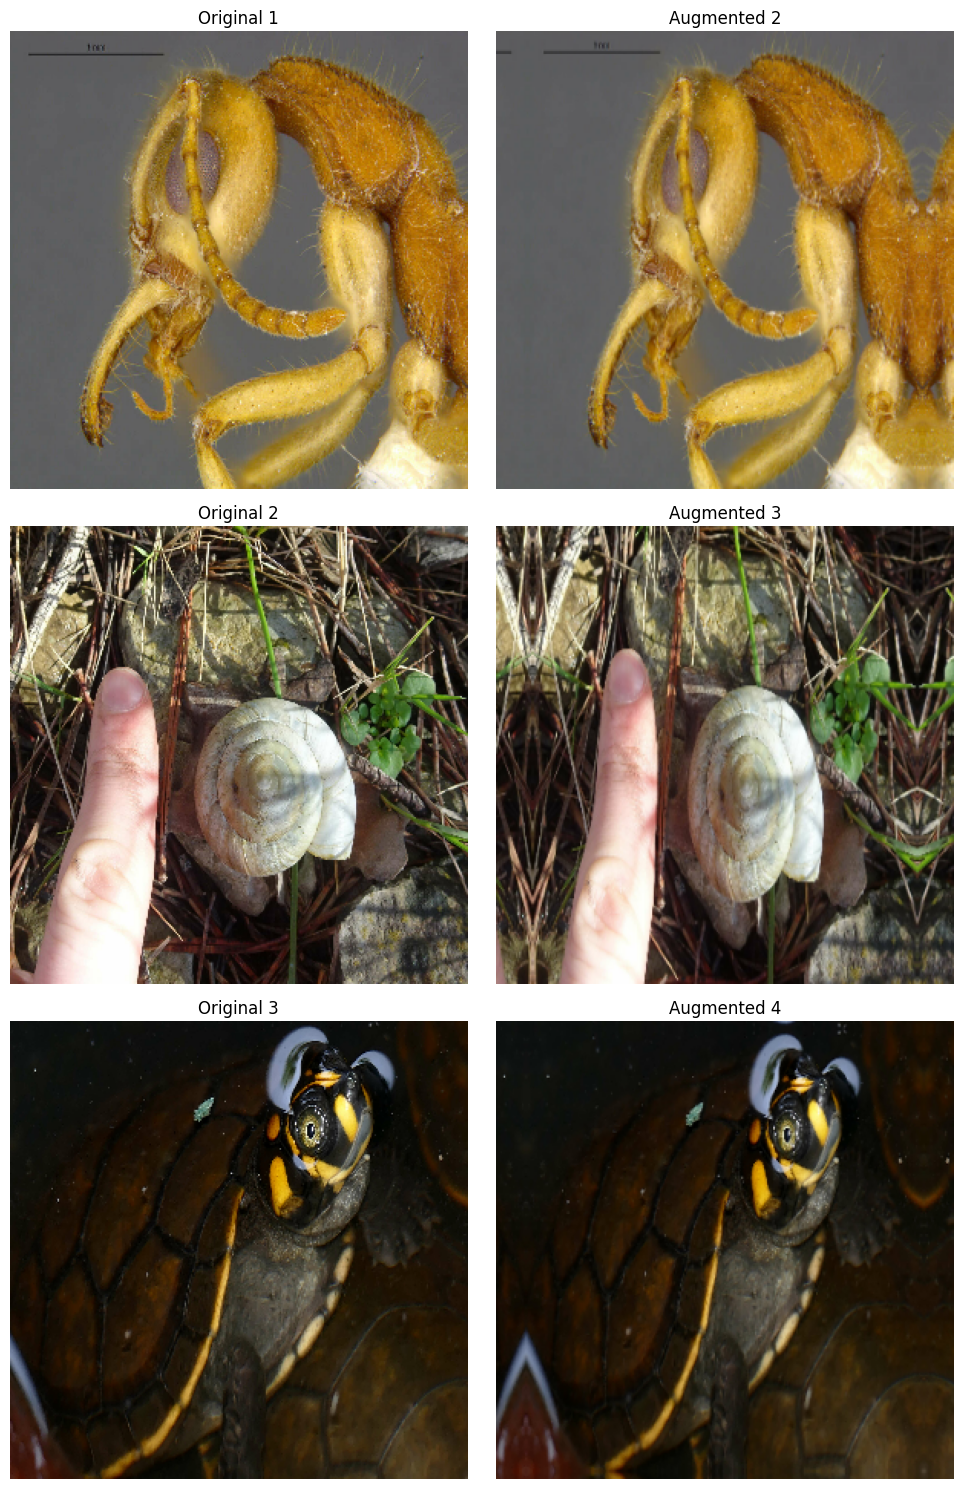

In [12]:
visualize_augmentations(
    train_ds_raw,
    num_examples=3,
    use_translation=False,
    use_rotation=False,
    use_zoom=True,
    use_flip=False,
    use_contrast=False,
    use_saturation=False,
    use_brightness=False,
    strong_factor = 0.2 ,
    weak_factor = 0.3
)


## 6.4. Model Creation Function

In [ ]:
def create_model(input_shape,
                  model = "xception",
                  use_translation=False,
                  use_rotation=False,
                  use_zoom=False,
                  use_flip=False,
                  use_contrast=False,
                  use_saturation=False,
                  use_brightness=False,
                  strong_factor = 0.0,
                  weak_factor= 0.0,
                  dense_units=0,
                  dropout_rate=0.0,
                  n_classes=N_CLASSES):

    input_layer = Input(shape=input_shape)

    x = apply_augmentations(
        inputs= input_layer,
        use_translation=use_translation,
        use_rotation=use_rotation,
        use_zoom=use_zoom,
        use_flip=use_flip,
        use_contrast=use_contrast,
        use_saturation=use_saturation,
        use_brightness=use_brightness,
        strong_factor=strong_factor,
        weak_factor=weak_factor
    )

    x = Rescaling(1/127.5, offset=-1)(x) 

    if model == "xception":
      base_model = Xception(include_top=False, weights="imagenet", input_shape=input_shape)
      base_model.trainable = False

    if model == "ResNet50V2":
      base_model = ResNet50V2(include_top=False, weights="imagenet", input_shape=input_shape)
      base_model.trainable = False

    x = base_model(x, training=False)

    x = GlobalAveragePooling2D()(x)


    if dropout_rate > 0 and dense_units == 0:
         x = Dropout(dropout_rate)(x)

    if dense_units > 0:
        x = Dense(dense_units, activation='relu', kernel_initializer='he_normal', use_bias=False)(x)
        x = BatchNormalization()(x)
        if dropout_rate > 0:
            x = Dropout(dropout_rate)(x)

    outputs = Dense(n_classes, activation='softmax')(x)

    model = Model(inputs=input_layer, outputs=outputs)

    return model

## 6.5. Training Function

In [ ]:
def train(train_ds = train_ds_raw, val_ds = val_ds_raw, test_ds = test_ds_raw):

    # 1. Initialize W&B run
    run = wandb.init(project=PROJECT_NAME, name = 'no aug')
    config = wandb.config

    # 2. Load Data
    batch_size = config.batch_size

    train_ds = train_ds.shuffle(buffer_size=1000, reshuffle_each_iteration=True)
    train_ds = train_ds.batch(batch_size)
    train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

    val_ds = val_ds.batch(batch_size)
    val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

    test_ds = test_ds.batch(batch_size)
    test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

    # 3. Build Model using config parameters
    model = create_model(
        input_shape=INPUT_SHAPE,
        model=config.model,
        use_translation=config.use_translation,
        use_rotation=config.use_rotation,
        use_zoom=config.use_zoom,
        use_flip=config.use_flip,
        use_contrast=config.use_contrast,
        use_saturation=config.use_saturation,
        use_brightness=config.use_brightness,
        strong_factor=config.strong_factor,
        weak_factor=config.weak_factor,
        dense_units=config.dense_units,
        dropout_rate=config.dropout_rate,
        n_classes=N_CLASSES
      )

    # 4. Select Optimizer
    if config.optimizer == "adam":
        optimizer = Adam(learning_rate=config.learning_rate)
    if config.optimizer == "RMSprop":
        optimizer = RMSprop(learning_rate=config.learning_rate)

    # 5. Define Metrics
    categorical_accuracy = CategoricalAccuracy(name="accuracy")
    precision = Precision(name="precision")
    recall = Recall(name="recall")
    macro_f1_score = F1Score(average="macro", name="macro_f1_score")
    metrics = [
            categorical_accuracy,
            precision,
            recall,
            macro_f1_score,
            ]

    # 6. Define Callbacks
    callbacks = [
        WandbMetricsLogger(log_freq='epoch'),

        WandbModelCheckpoint(
            filepath=f"model_{run.name}_best.keras",
            monitor=METRIC_TO_MONITOR,
            mode=MODE,
            save_best_only=True,
            save_weights_only=False,
        ),

        EarlyStopping(monitor=METRIC_TO_MONITOR, mode=MODE, patience=config.es_patience, verbose=1, restore_best_weights=True),

        ReduceLROnPlateau(monitor=METRIC_TO_MONITOR, mode=MODE, patience=config.lr_patience, factor=config.lr_reduce_factor, min_delta=config.min_delta, verbose=1)
    ]

    # 7. Select Loss, Compile and Train Model
    if config.loss == "categorical_crossentropy":
        loss = CategoricalCrossentropy(label_smoothing=config.label_smoothing)

        model.compile(loss=loss, optimizer=optimizer, metrics=metrics)

        print(f"--- Starting W&B Run with Config: {dict(config)} ---")
        _ = model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=EPOCHS,
            callbacks=callbacks,
            verbose=1,
            class_weight=class_weights_dict,
        )

    if config.loss == "categorical_focal_crossentropy":
        loss = CategoricalFocalCrossentropy(gamma=config.gamma, alpha=alpha_weights, label_smoothing=config.label_smoothing)

        model.compile(loss=loss, optimizer=optimizer, metrics=metrics)

        print(f"--- Starting W&B Run with Config: {dict(config)} ---")
        _ = model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=EPOCHS,
            callbacks=callbacks,
            verbose=1,
        )

    # 8. Log Test
    test_results = model.evaluate(test_ds, verbose=1)
    metrics_dict = { f"test_{n}": v for n, v in zip(model.metrics_names, test_results) }
    wandb.log(metrics_dict)

    # 9. Finish W&B Run
    print(f"--- Evaluating Model ---")
    wandb.finish()
    print(f"--- Finished W&B Run ---")

# 7. Extract Class Weights

__`Step 13`__ Calculate class weights to handle class imbalance.

For that we use the formula: <br>
$$
\text{weight}_i = \frac{\text{Total Samples}}{\text{Number of Classes} \times \text{Count of Class } i}
$$

## 7.1. Dictionary

In [ ]:
label_counts = Counter()
total_samples = 0

for features, label_tensor in train_ds_raw:
    integer_label = np.argmax(label_tensor.numpy())
    label_counts[integer_label] += 1
    total_samples += 1

class_weights_dict = {}

for i in range(N_CLASSES):
    count = label_counts.get(i)
    weight = total_samples / (N_CLASSES * count)
    class_weights_dict[i] = weight

## 7.2. Array

__`Step 14`__ Transform into array to alpha focal loss parameter.

In [ ]:
total_samples = sum(label_counts.values())
alpha_weights = np.zeros(N_CLASSES)
for i in range(N_CLASSES):
    count = label_counts.get(i)
    alpha_weights[i] = total_samples / (N_CLASSES * count)

# 8. Training the Model

__`Step 15`__ Train our model.

In [ ]:
wandb.agent(sweep_id, function=train, count=1)

wandb: Agent Starting Run: hqde2il1 with config:
wandb: 	batch_size: 750
wandb: 	dense_units: 128
wandb: 	dropout_rate: 0.10521598843788782
wandb: 	es_patience: 25
wandb: 	gamma: 1.0461139526339738
wandb: 	label_smoothing: 0.07333693134130108
wandb: 	learning_rate: 6.859458235313327e-05
wandb: 	loss: categorical_focal_crossentropy
wandb: 	lr_patience: 12
wandb: 	lr_reduce_factor: 0.3
wandb: 	min_delta: 0.0001
wandb: 	min_lr: 1e-08
wandb: 	model: xception
wandb: 	optimizer: adam
wandb: 	strong_factor: 0.1
wandb: 	use_brightness: False
wandb: 	use_contrast: False
wandb: 	use_flip: True
wandb: 	use_rotation: False
wandb: 	use_saturation: False
wandb: 	use_translation: False
wandb: 	use_zoom: False
wandb: 	weak_factor: 0.2


83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


wandb: WARNING When using `save_best_only`, ensure that the `filepath` argument contains formatting placeholders like `{epoch:02d}` or `{batch:02d}`. This ensures correct interpretation of the logged artifacts.


--- Starting W&B Run with Config: {'batch_size': 750, 'dense_units': 128, 'dropout_rate': 0.10521598843788782, 'es_patience': 25, 'gamma': 1.0461139526339738, 'label_smoothing': 0.07333693134130108, 'learning_rate': 6.859458235313327e-05, 'loss': 'categorical_focal_crossentropy', 'lr_patience': 12, 'lr_reduce_factor': 0.3, 'min_delta': 0.0001, 'min_lr': 1e-08, 'model': 'xception', 'optimizer': 'adam', 'strong_factor': 0.1, 'use_brightness': False, 'use_contrast': False, 'use_flip': True, 'use_rotation': False, 'use_saturation': False, 'use_translation': False, 'use_zoom': False, 'weak_factor': 0.2} ---
Epoch 1/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 388s 21s/step - accuracy: 0.0038 - loss: 5.8357 - macro_f1_score: 0.0036 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.0129 - val_loss: 5.4550 - val_macro_f1_score: 0.0032 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 6.8595e-05
Epoch 2/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 40s 4s/step - accuracy: 0.0111 - loss: 5.6

# 9. Rebuild Best Model

Since this notebook was re-used to explore different models we finish up by rebuilding the best model, from sweep "happy-sweep-3".

__`Step 16`__ We insert the model's configurations.

In [ ]:
baseline_config = {
    'model':               'xception',
    'batch_size':          64,
    'dropout_rate':        0.10521598843788782,
    'label_smoothing':     0.07333693134130108,
    'gamma':               1.0461139526339738,
    'dense_units':         128,
    #'augmentation':        False,
    #'augmentation_factor': 0.4384658636338782,
    'optimizer':           'adam',
    'loss':                'categorical_focal_crossentropy',
    'learning_rate':       6.859458235313327e-05,
}

In [ ]:
BATCH_SIZE = baseline_config['batch_size']

train_ds = train_ds_raw.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds_raw.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds  = test_ds_raw.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

__`Step 17`__ We load the model from the keras file and continue to train it in order to get to our final model.

In [ ]:
# Resume the W&B run
run = wandb.init(project="family-classification-v6", id="0etld4xa", resume="must")

# Reload the best checkpoint saved during the earlier run
model = load_model("model_happy-sweep-3_best.keras", compile=False)

# Setting same loss, optimizer and metrics
loss = CategoricalFocalCrossentropy(
    gamma           =  baseline_config['gamma'],
    alpha           = alpha_weights,
    label_smoothing = baseline_config['label_smoothing'],
)

optimizer = Adam(learning_rate=baseline_config['learning_rate'])

metrics = [
    CategoricalAccuracy(name="accuracy"),
    Precision(name="precision"),
    Recall(name="recall"),
    F1Score(average="macro", name="macro_f1_score"),
]


# Re-compile with the same settings
model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

# Continue training
model.fit(train_ds,
          validation_data=val_ds,
          epochs=200,
          callbacks=[
              wandb.keras.WandbMetricsLogger(log_freq="epoch"),
              EarlyStopping(monitor=METRIC_TO_MONITOR, mode=MODE, patience=15, verbose=1, restore_best_weights=True),
          ])